In [1]:
import anndata
import matplotlib.pyplot as plt

import dtangle

In [2]:
adata_sum = anndata.read_h5ad("./data/GSE19830_sum.h5ad")
adata_sum

AnnData object with n_obs × n_vars = 42 × 13934
    obs: 'sample_name', 'cel_version', 'nrows', 'ncols', 'algorithm', 'sample_geo_accession', 'sample_name_meta', 'sample_title', 'sample_source_name_ch1', 'sample_organism_ch1', 'sample_platform_id', 'sample_series_id', 'file', 'file_size', 'file_url', 'accession', 'fraction_liver', 'fraction_brain', 'fraction_lung'
    var: 'gene_id', 'n_probes', 'converged'
    uns: 'normalization', 'summarization'

In [6]:
adata_ref = adata_sum[
    (adata_sum.obs["fraction_liver"] == 1)
    | (adata_sum.obs["fraction_brain"] == 1)
    | (adata_sum.obs["fraction_lung"] == 1)
]

adata_source = adata_sum[
    (adata_sum.obs["fraction_liver"] != 1)
    & (adata_sum.obs["fraction_brain"] != 1)
    & (adata_sum.obs["fraction_lung"] != 1)
]

adata_ref.obs["ref_organ"] = None
adata_ref.obs.loc[adata_ref.obs["fraction_liver"] == 1, "ref_organ"] = "liver"
adata_ref.obs.loc[adata_ref.obs["fraction_brain"] == 1, "ref_organ"] = "brain"
adata_ref.obs.loc[adata_ref.obs["fraction_lung"] == 1, "ref_organ"] = "lung"

assert adata_ref.n_obs + adata_source.n_obs == adata_sum.n_obs
adata_ref.obs["ref_organ"].value_counts()

/tmp/ipykernel_8761/4204185366.py:13: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_ref.obs["ref_organ"] = None


ref_organ
liver    3
brain    3
lung     3
Name: count, dtype: int64

In [7]:
dtangle.deconvolut(
    adata_source,
    references=adata_ref,
    reference_annotation_col="ref_organ",
    data_type="microarray-gene",
    n_markers=20,
)

/home/malte/Dokumente/Github/dtangle/src/dtangle/_deconvolution.py:115: ImplicitModificationWarning: Setting element `.obsm['dtangle']` of view, initializing view as actual.
  adata.obsm[key_added] = estimates_df


Text(0, 0.5, 'Estimated fraction')

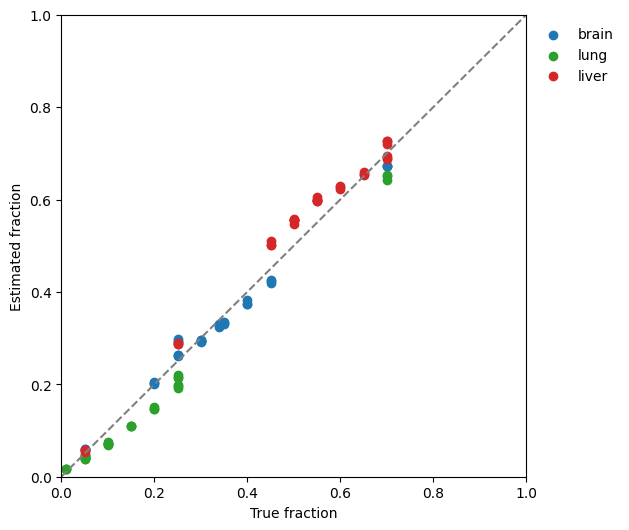

In [8]:
fig, ax = plt.subplots(figsize=(6, 6))
for cell_type, color in zip(
    ["brain", "lung", "liver"],
    ["tab:blue", "tab:green", "tab:red"],
    strict=True,
):
    ax.scatter(
        x=adata_source.obs[f"fraction_{cell_type}"],
        y=adata_source.obsm["dtangle"][cell_type],
        c=color,
        label=cell_type,
    )
ax.legend(
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(1, 1),
)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.plot([0, 1], [0, 1], c="gray", ls="--")

ax.set_xlabel("True fraction")
ax.set_ylabel("Estimated fraction")